In [4]:
import sys
!{sys.executable} -m pip install matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

GOLD_PATH = Path("../data/refined_gold")

fluxo = pd.read_parquet(GOLD_PATH / "fluxo_concorrente_analitico.parquet")
geo = pd.read_parquet(GOLD_PATH / "concorrente_geografia.parquet")

  Using cached matplotlib-3.7.5-cp38-cp38-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (9.2 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached contourpy-1.1.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (301 kB)
  Using cached pillow-10.4.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.4 MB)
  Using cached fonttools-4.57.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.7 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.4.7-cp38-cp38-manylinux_2_5_x86_64.manylinux1_x86_64.whl (1.2 MB)


Fluxo Médio por Dia da Semana e Período

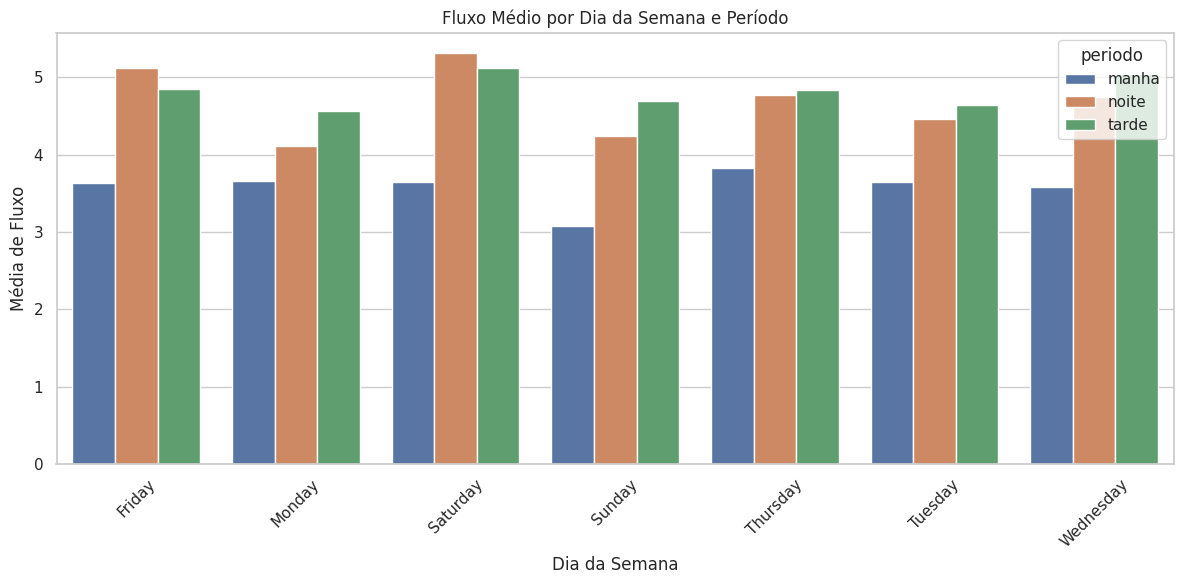

In [ ]:
# ============================================================
# Análise: Fluxo médio por dia da semana e período
# Objetivo:
#   Calcular a média do fluxo agrupando por dia da semana e período
#   (ex: manhã, tarde, noite) e visualizar o resultado em gráfico de barras.
# ============================================================

# Agregação dos dados
# ------------------------------------------------------------
# Agrupamos os dados pelas colunas:
#   - dia_semana
#   - periodo
# E calculamos a média da coluna "media_fluxo"
# O reset_index() transforma o resultado novamente em DataFrame
# (evita manter estrutura de índice hierárquico após o groupby)

fluxo_media = (
    fluxo
    .groupby(["dia_semana", "periodo"], as_index=False)["media_fluxo"]
    .mean()
)

# Boa prática:
# - Usar as_index=False evita necessidade de reset_index()
# - Manter a identação encadeada melhora legibilidade


# Configuração da figura
# ------------------------------------------------------------
# Define tamanho da figura para melhor visualização

plt.figure(figsize=(12, 6))


# Criação do gráfico de barras
# ------------------------------------------------------------
# sns.barplot:
#   - x: eixo horizontal (dia da semana)
#   - y: valor da média do fluxo
#   - hue: separação por período (cores diferentes)
#
# Observação:
# O Seaborn já calcula estimativas estatísticas por padrão,
# mas como já agregamos os dados, estamos apenas plotando valores prontos.

sns.barplot(
    data=fluxo_media,
    x="dia_semana",
    y="media_fluxo",
    hue="periodo"
)


# Customização do gráfico
# ------------------------------------------------------------
# Título claro e descritivo
plt.title("Fluxo Médio por Dia da Semana e Período")

# Rotaciona os rótulos do eixo X para evitar sobreposição
plt.xticks(rotation=45)

# Rótulos dos eixos (boa prática: sempre explicitar unidade ou contexto)
plt.ylabel("Média de Fluxo")
plt.xlabel("Dia da Semana")

# Ajusta automaticamente os espaçamentos
plt.tight_layout()


# Exibição do gráfico
# ------------------------------------------------------------
plt.show()

Fluxo Médio Geral por Período

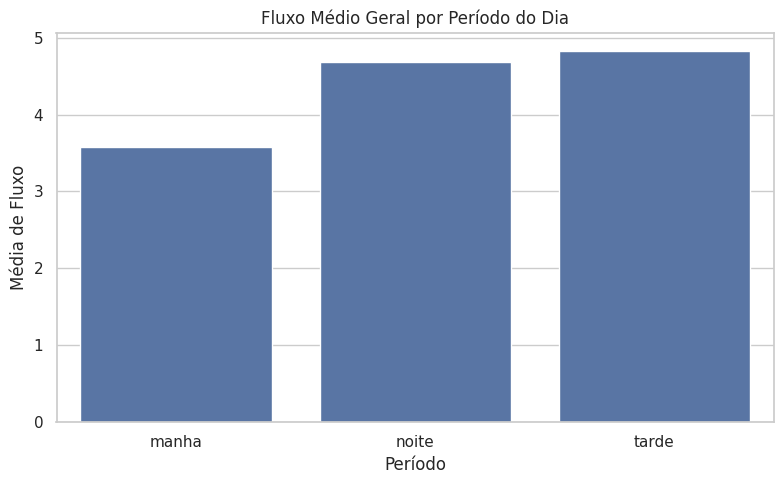

In [ ]:
# ============================================================
# Análise: Fluxo médio geral por período do dia
# Objetivo:
#   Calcular a média do fluxo considerando apenas o período
#   (ex: manhã, tarde, noite) e visualizar em gráfico de barras.
# ============================================================

# Agregação dos dados
# ------------------------------------------------------------
# Agrupamos os dados pela coluna "periodo"
# e calculamos a média da variável "media_fluxo".
#
# Boa prática:
# - Utilizar as_index=False evita precisar usar reset_index()
# - Mantém o resultado como DataFrame estruturado

fluxo_periodo = (
    fluxo
    .groupby("periodo", as_index=False)["media_fluxo"]
    .mean()
)


# Configuração da figura
# ------------------------------------------------------------
# Define tamanho adequado para visualização clara

plt.figure(figsize=(8, 5))


# Criação do gráfico
# ------------------------------------------------------------
# Como já calculamos a média manualmente,
# o seaborn apenas exibirá os valores agregados.

sns.barplot(
    data=fluxo_periodo,
    x="periodo",
    y="media_fluxo"
)


# Customização do gráfico
# ------------------------------------------------------------
# Título claro e descritivo
plt.title("Fluxo Médio Geral por Período do Dia")

# Rótulos dos eixos (sempre importante explicitar)
plt.ylabel("Média de Fluxo")
plt.xlabel("Período")

# Ajuste automático de layout
plt.tight_layout()


# Exibição do gráfico
# ------------------------------------------------------------
plt.show()

Distribuição de Faixa de Preço

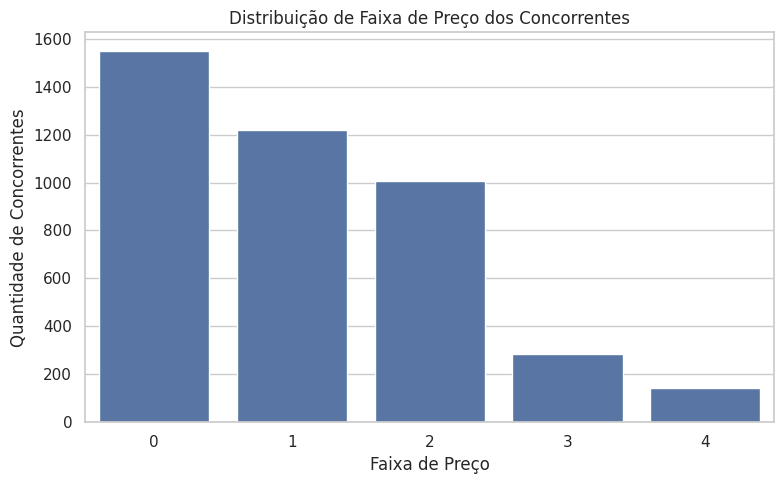

In [17]:
# ============================================================
# Análise: Distribuição da faixa de preço dos concorrentes
# Objetivo:
#   Visualizar a quantidade de concorrentes em cada faixa de preço
#   utilizando um gráfico de contagem (countplot).
# ============================================================

# 1) Configuração da figura
# ------------------------------------------------------------
# Define tamanho adequado para visualização.
# O tamanho deve ser proporcional à quantidade de categorias no eixo X.

plt.figure(figsize=(8, 5))


# 2) Criação do gráfico de contagem
# ------------------------------------------------------------
# sns.countplot:
#   - Conta automaticamente a frequência de cada categoria
#   - Não é necessário realizar groupby manual
#
# Boa prática:
# - Garantir que a coluna "faixa_preco" esteja tratada (sem valores nulos)
# - Padronizar categorias antes da visualização, se necessário

sns.countplot(
    data=geo,
    x="faixa_preco"
)


# 3) Customização do gráfico
# ------------------------------------------------------------
# Título claro e descritivo
plt.title("Distribuição de Faixa de Preço dos Concorrentes")

# Rótulos dos eixos explícitos
plt.xlabel("Faixa de Preço")
plt.ylabel("Quantidade de Concorrentes")

# Ajuste automático de layout
plt.tight_layout()


# 4) Exibição do gráfico
# ------------------------------------------------------------
plt.show()

Fluxo médio por dia e período:

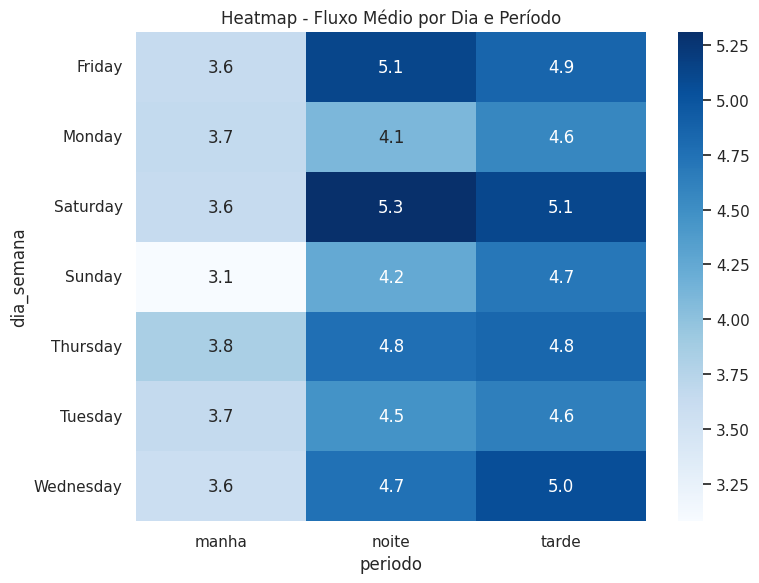

In [18]:
# ============================================================
# Análise: Heatmap do fluxo médio por dia da semana e período
# Objetivo:
#   Transformar os dados agregados em formato de matriz (pivot)
#   e visualizar a intensidade do fluxo médio através de heatmap.
# ============================================================

# 1) Criação da tabela pivot
# ------------------------------------------------------------
# Converte o DataFrame "fluxo_media" em formato matricial:
#   - Linhas: dia da semana
#   - Colunas: período do dia
#   - Valores: média do fluxo
#
# Boa prática:
# - Garantir que "fluxo_media" já esteja previamente agregada
# - Verificar ausência de valores duplicados na combinação (dia_semana, periodo)

pivot_fluxo = fluxo_media.pivot(
    index="dia_semana",
    columns="periodo",
    values="media_fluxo"
)


# 2) Configuração da figura
# ------------------------------------------------------------
# Define tamanho adequado para leitura confortável dos valores

plt.figure(figsize=(8, 6))


# 3) Criação do heatmap
# ------------------------------------------------------------
# sns.heatmap:
#   - annot=True: exibe os valores dentro das células
#   - fmt=".1f": formata valores com 1 casa decimal
#   - cmap="Blues": define escala de cores
#
# Boa prática:
# - Escolher colormap consistente com padrão visual do projeto
# - Garantir que não existam valores NaN (ou tratá-los previamente)

sns.heatmap(
    pivot_fluxo,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)


# 4) Customização do gráfico
# ------------------------------------------------------------
plt.title("Heatmap - Fluxo Médio por Dia e Período")

# Ajuste automático de layout para evitar cortes
plt.tight_layout()


# 5) Exibição do gráfico
# ------------------------------------------------------------
plt.show()